In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import polars

In [2]:
df = pd.read_csv("../data/raw/stores_sales.csv")

# EDA

## 1. Overview

### 1.1 Data Overview

In [3]:
df.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310


### 1.1.1 Datatypes and nulls

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2121 entries, 0 to 2120
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         2121 non-null   int64  
 1   Order ID       2121 non-null   object 
 2   Order Date     2121 non-null   object 
 3   Ship Date      2121 non-null   object 
 4   Ship Mode      2121 non-null   object 
 5   Customer ID    2121 non-null   object 
 6   Customer Name  2121 non-null   object 
 7   Segment        2121 non-null   object 
 8   Country        2121 non-null   object 
 9   City           2121 non-null   object 
 10  State          2121 non-null   object 
 11  Postal Code    2121 non-null   int64  
 12  Region         2121 non-null   object 
 13  Product ID     2121 non-null   object 
 14  Category       2121 non-null   object 
 15  Sub-Category   2121 non-null   object 
 16  Product Name   2121 non-null   object 
 17  Sales          2121 non-null   float64
 18  Quantity

Info:
- Null Values = 0
- Dtypes needs correcting
- Add more datetime columns

#### 1.1.2 Correcting names for consistency

In [5]:
df.columns = (df.columns
              .str.strip()
              .str.lower()
              .str.replace("-", "_", regex=False)
              .str.replace(" ", "_", regex=False)
              .str.replace(r"_+", "_", regex=True))


#### 1.1.3 Changing dtypes and adding features

In [6]:
# Adding new and correcting features and datatypes

df["order_id"] = df["order_id"].astype("string")
df["order_date"] = pd.to_datetime(df["order_date"], format="%m/%d/%Y")
df["ship_date"] = pd.to_datetime(df["ship_date"], format="%m/%d/%Y")
df["ship_mode"] = pd.Categorical(df["ship_mode"])
df["customer_id"] = df["customer_id"].astype("string")
df["customer_name"] = df["customer_name"].astype("string")
df["segment"] = pd.Categorical(df["segment"])
df["country"] = pd.Categorical(df["country"])
df["city"] = df["city"].astype("string")
df["state"] = df["state"].astype("string")
df["postal_code"] = pd.Categorical(df["postal_code"])
df["region"] = pd.Categorical(df["region"])
df["product_id"] = df["product_id"].astype("string")
df["category"] = pd.Categorical(df["category"])
df["sub_category"] = pd.Categorical(df["sub_category"])
df["product_name"] = df["product_name"].astype("string")
df["order_year"] = pd.to_datetime(df["order_date"]).dt.year
df["order_quarter"] = pd.to_datetime(df["order_date"]).dt.quarter
df["order_month"] = pd.to_datetime(df["order_date"]).dt.month
df["order_day"] = df["order_date"].dt.day
df["order_weekday"] = df["order_date"].dt.weekday
df["order_weekend"] = (df["order_date"].dt.weekday >=5)


### 1.2 Correlations

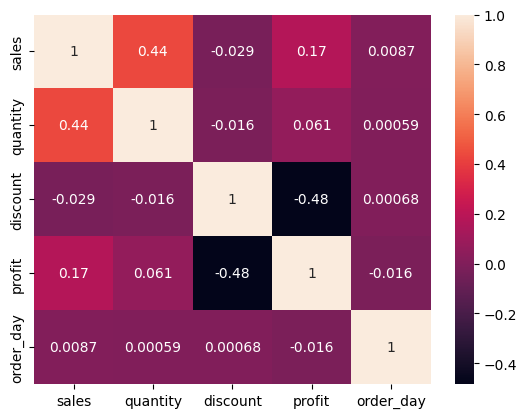

In [7]:
# Seaborn heatmap
sns.heatmap(df[["sales", "quantity", "discount", "profit", "order_day"]].corr(numeric_only=True), annot=True);

Profit and Discount
- Large negative correlation.
- Frequencies of discounts too many?
- Too high discounts?
- Customers only shop on discounts?

Profit and Quantity
- Small positive correlation.
- Number of items sold has small positive impact on profits.
- Can we figure out why?
- Possibilites to increase profits?

Profit and Sales
- Good baseline for improvements.


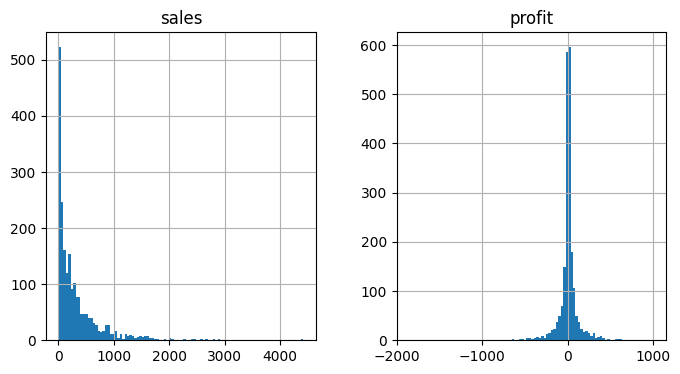

In [8]:
df[["sales", "profit"]].hist(bins=100, figsize=(8,4));

### 1.3 Checking Profits & Discount Rates

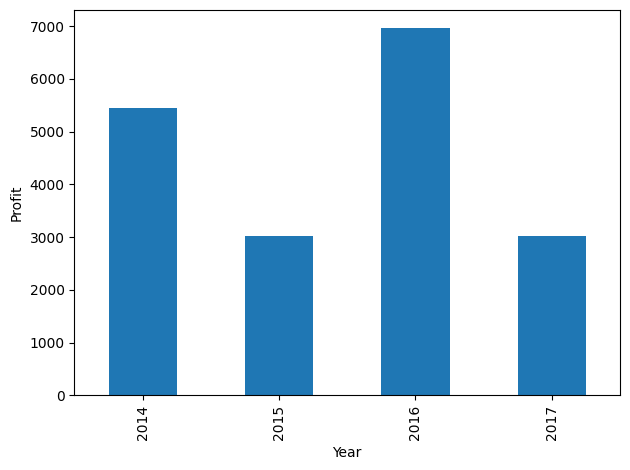

In [9]:
# Plot
agg = df.groupby("order_year")["profit"].sum()
ax = agg.plot(kind="bar")
plt.ylabel("Profit")
plt.xlabel("Year")
plt.tight_layout()
plt.show()

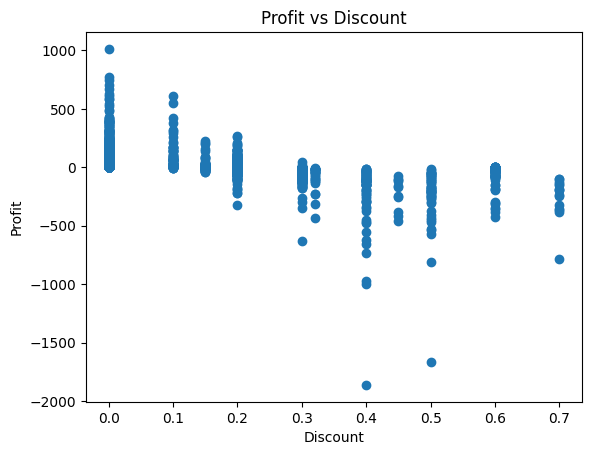

In [10]:
# Creating scatter plot(Discount rates vs Profit)
plt.scatter(df["discount"], df["profit"])
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.title("Profit vs Discount")
plt.show()

In [11]:
# Number of profitable sales vs losing sales
n_profit  = (df["profit"] > 0).sum()
n_loss = (df["profit"] < 0).sum()
n_break_even   = (df["profit"] == 0).sum()

# Proportion of profitable sales vs losing sales
tot = len(df)
p_profit  = n_profit / tot
p_loss = n_loss / tot
p_break_even   = n_break_even / tot

print("Number of profitable sales:", n_profit)
print("Number of losing sales:", n_loss)
print("Number of break-even sales:", n_break_even)
print(f"Proportion Profit: {p_profit * 100:.1f}%")
print(f"Proportion Loss: {p_loss * 100:.1f}%")
print(f"Proportion Break-even: {p_break_even * 100:.1f}%")

print(df.groupby("sub_category", observed=False)["profit"].sum())



Number of profitable sales: 1374
Number of losing sales: 714
Number of break-even sales: 33
Proportion Profit: 64.8%
Proportion Loss: 33.7%
Proportion Break-even: 1.6%
sub_category
Bookcases      -3472.5560
Chairs         26590.1663
Furnishings    13059.1436
Tables        -17725.4811
Name: profit, dtype: float64


##### Profit and losses
Things to consider:
- Look into lowering or removing discounts on tables and bookcases
- Look into possibly lowering costs on items.
- Look into possibly increase prices.
- We're starting to lose money at rates > 20%.
- Consider discount cap at 20%?
- Decrease the frequency of discount?


### 1.4 Distributions

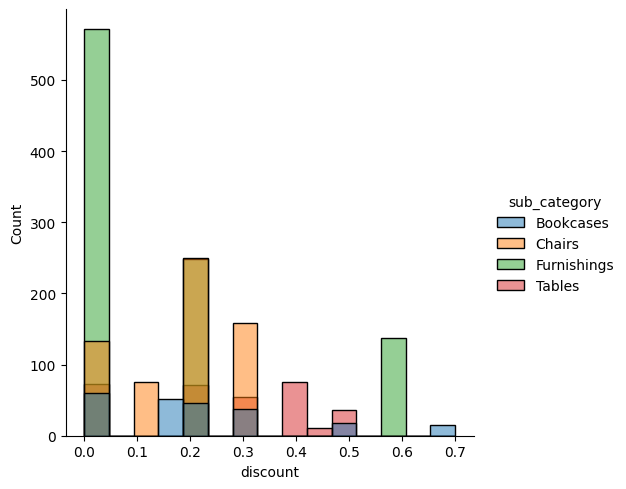

In [12]:
sns.displot(df, x="discount", hue="sub_category");

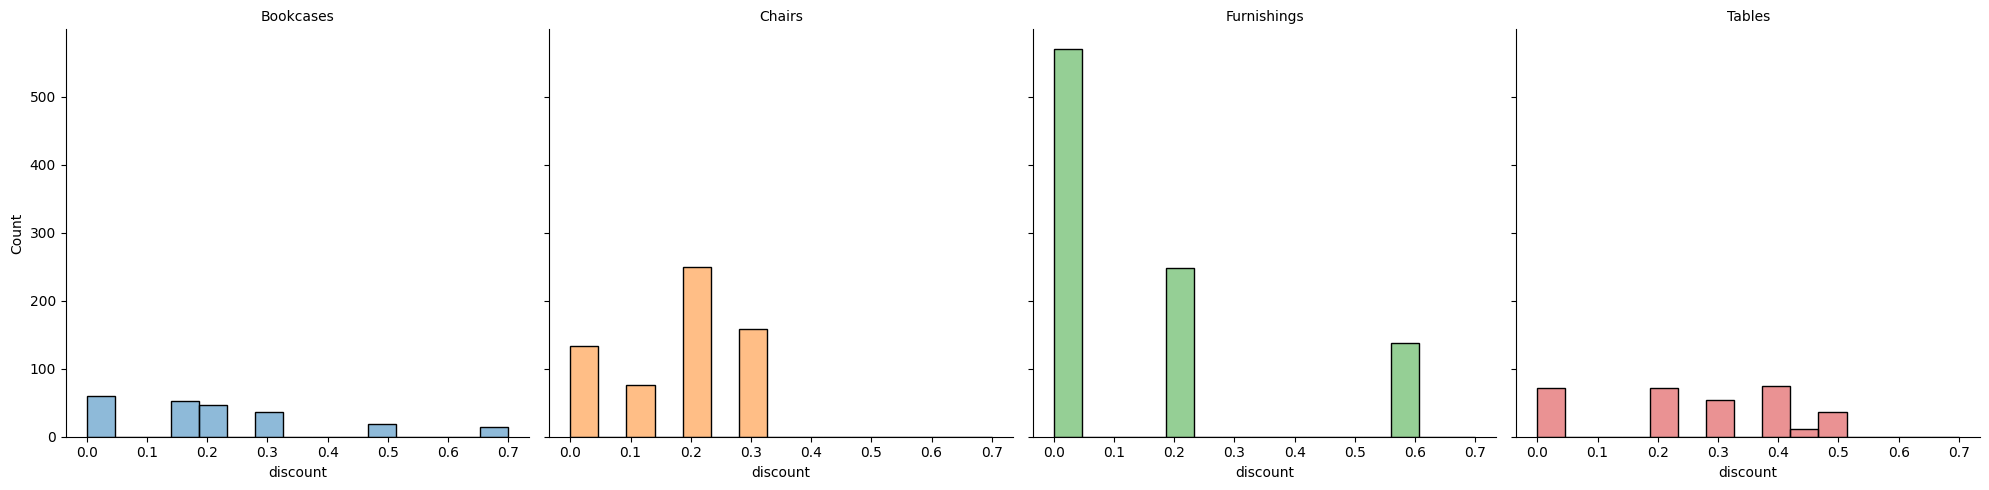

In [13]:
sns.displot(df, x="discount", col="sub_category", hue="sub_category", legend=False).set_titles("{col_name}");

## 2. Scenario (Discount Capped at 20%)

In [14]:
# Creating new features for discount cap

# Cost feature
df["cost"] = (df["sales"] - df["profit"])

# Price before discount
df["price_before_discount"] = df["sales"] / (1 - df["discount"])

# All discounts above > 20% will be capped at 20%
df["discount_cap20"] = df["discount"].clip(upper=0.20)

# New sales with cap
df["sales_cap20"] = df["price_before_discount"] * (1 - df["discount_cap20"])

# New profits with discount cap
df["profit_cap20"] = df["sales_cap20"] - df["cost"]


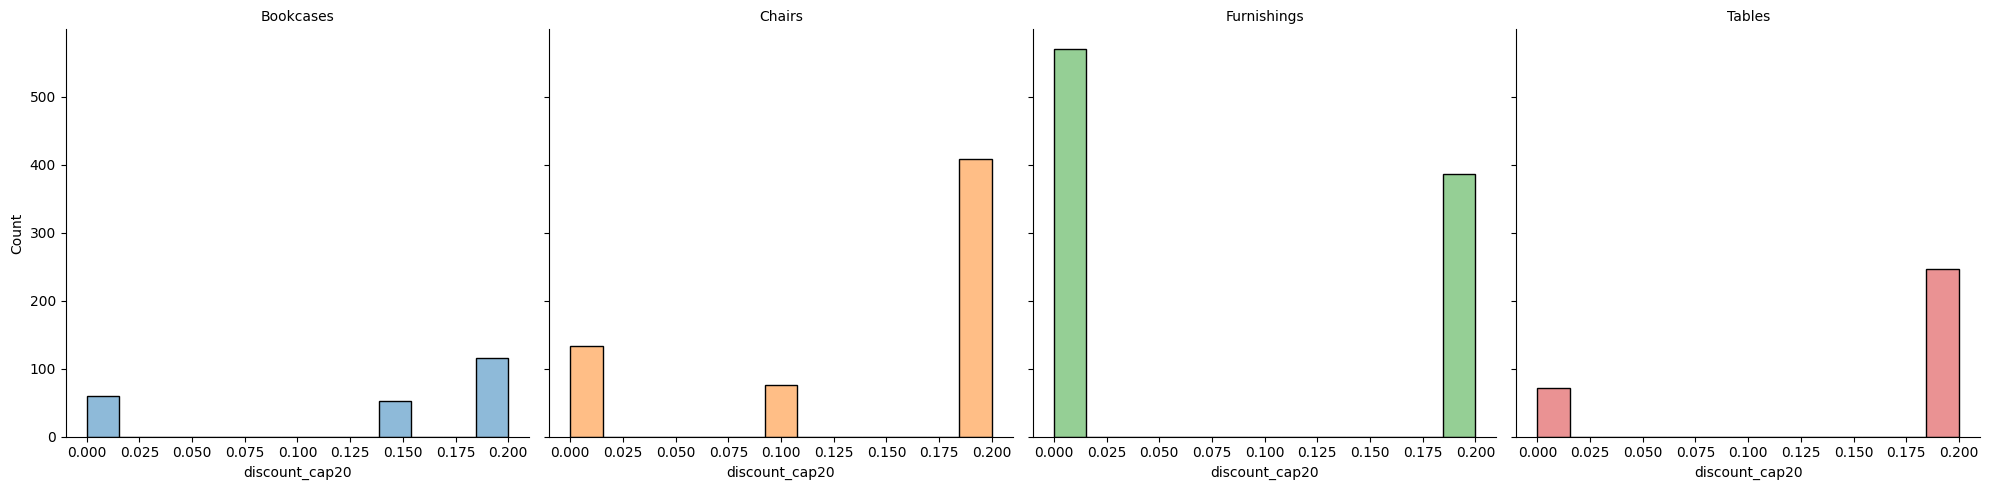

In [15]:
sns.displot(df, x="discount_cap20", col="sub_category", hue="sub_category", legend=False).set_titles("{col_name}");

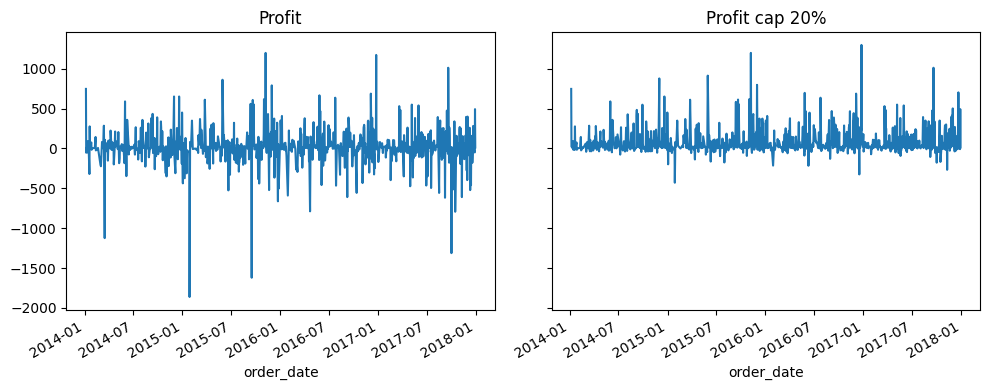

In [32]:

s1 = df.groupby("order_date")["profit"].sum()
s2 = df.groupby("order_date")["profit_cap20"].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

s1.plot(ax=axes[0], title="Profit")
s2.plot(ax=axes[1], title="Profit cap 20%")

plt.tight_layout()
plt.show()


### 3.0 Results

In [31]:
current = df["profit"].sum()
cap20 = df["profit_cap20"].sum()

# Number of profitable sales vs losing sales
n_profit_cap20  = (df["profit_cap20"] > 0).sum()
n_loss_cap20 = (df["profit_cap20"] < 0).sum()
n_break_even_cap20   = (df["profit_cap20"] == 0).sum()

# Proportion of profitable sales vs losing sales
tot = len(df)
p_profit_cap20  = n_profit_cap20 / tot
p_loss_cap20 = n_loss_cap20 / tot
p_break_even_cap20   = n_break_even_cap20 / tot

print("Number of profitable sales:", n_profit)
print("Number of losing sales:", n_loss)
print("Number of break-even sales:", n_break_even)
print(f"Proportion Profit: {p_profit * 100:.1f}%")
print(f"Proportion Loss: {p_loss * 100:.1f}%")
print(f"Proportion Break-even: {p_break_even * 100:.1f}%")

print("Number of profitable sales cap (capped):", n_profit_cap20)
print("Number of losing sales cap (capped):", n_loss_cap20)
print("Number of break-even sales (capped):", n_break_even_cap20)
print(f"Proportion Profit (capped): {p_profit_cap20 * 100:.1f}%")
print(f"Proportion Loss (capped): {p_loss_cap20 * 100:.1f}%")
print(f"Proportion Break-even (capped): {p_break_even_cap20 * 100:.1f}%")

print(df.groupby("sub_category", observed=False)["profit"].sum())
print(df.groupby("sub_category", observed=False)["profit_cap20"].sum())


print(f"Current total profit: {current:,.2f}")
print(f"Cap 20% total profit: {cap20:,.2f}")

# Profit gained increase with discount cap
profit_gain = ((cap20 - current) / current * 100)
print(f"Profit gain(%) from cap: {profit_gain:,.2f} %")


Number of profitable sales: 1374
Number of losing sales: 714
Number of break-even sales: 33
Proportion Profit: 64.8%
Proportion Loss: 33.7%
Proportion Break-even: 1.6%
Number of profitable sales cap (capped): 1711
Number of losing sales cap (capped): 384
Number of break-even sales (capped): 26
Proportion Profit (capped): 80.7%
Proportion Loss (capped): 18.1%
Proportion Break-even (capped): 1.2%
sub_category
Bookcases      -3472.5560
Chairs         26590.1663
Furnishings    13059.1436
Tables        -17725.4811
Name: profit, dtype: float64
sub_category
Bookcases       8180.9732
Chairs         36590.9523
Furnishings    19703.8436
Tables         11774.9469
Name: profit_cap20, dtype: float64
Current total profit: 18,451.27
Cap 20% total profit: 76,250.72
Profit gain(%) from cap: 313.25 %
